# ppgtiAM classificaçãoPericias p1 cargaInicial-exploração-limpeza

Trabalho final da disciplina de Aprendizado de Máquina (prof Daniel Sabino) em 2026.1 (PPgTI/IMD/UFRN)

Membros:
- Bruno Silva
- Marlus Silva
- Selton Braz

Objetivo: *analisar a capacidade de classificação de processos judiciais quanto a necessidade de perícias médicas e indicação da área especializada, aplicando técnicas de aprendizado supervisionado e LLM.*

### Preparação e bibliotecas

In [ ]:
# executar qdo kernel local
%pip install pandas scipy seaborn matplotlib scikit-learn

In [1]:
# executar qdo kernel no google colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import pandas as pd
from pathlib import Path
import numpy as np

pd.set_option('display.max_columns', None)

data_path = Path('df_metadadosPericias.csv')
if not data_path.exists():
    data_path = '/content/drive/MyDrive/Colab Notebooks/Doutorado/discAprendMáquina/[AprendMáquina] ProjetoFinal/df_metadadosPericias.csv'

df_metadadosPericias = pd.read_csv(data_path)
print(f'Dataset carregado com sucesso de {data_path}')
print(f'Formato do dataset: {df_metadadosPericias.shape}')

Dataset carregado com sucesso de /content/drive/MyDrive/Colab Notebooks/Doutorado/discAprendMáquina/[AprendMáquina] ProjetoFinal/df_metadadosPericias.csv
Formato do dataset: (165499, 26)


### Amostra dos dados

In [11]:
print('Amostra inicial do dataset:')
display(df_metadadosPericias.head())

Amostra inicial do dataset:


,index,id_processo_judicial,nr_processo_judicial,dt_primeira_distribuicao,in_tutela_antecipada,nm_juizado,ds_cidade,codigo_assunto,ds_assunto_judicial,ds_complemento_assunto_judicial,detalhe_assunto_1,detalhe_assunto_2,id_perito,ds_especialidade,ds_complemento_especialidade,ds_status_pericia,dt_cadastro_pericia,dt_realizacao_pericia,ds_tipo_documento,ds_extensao,dt_inclusao,vara,triagem_peticao,tamanho_texto,label_especialidade,requer_pericia
0,178672,475347,0501383-21.2019.4.05.8404,2019-04-24 00:00:00,N,12a. Vara Federal - Pau dos Ferros,Pau dos Ferros,195,Direito Previdenciário,Benefícios em Espécie,Auxílio-Doença Previdenciário,NaN,273713.0,Médico,Ortopedista,Pendente,2019-05-07 15:09:32.913625,NaN,Petição Inicial,pdf,2019-04-24 12:33:02.747616,8404,1,12943,Ortopedista,S
1,37083,256155,0501266-12.2014.4.05.8402,2014-05-26 00:00:00,N,9a. Vara Federal,Caicó,195,Direito Previdenciário,Benefícios em Espécie,Aposentadoria por Invalidez,NaN,173007.0,Médico,Clínico Geral,Realizada,2014-06-04 14:45:07.455382,2014-07-03 11:31:01.517090,Petição Inicial,pdf,2014-05-25 10:35:41.873462,8402,1,9262,Clínico Geral,S
2,1247,97537,0500434-21.2010.4.05.8401,2010-08-18 00:00:00,N,13a. Vara Federal,Mossoró,9985,Direito Administrativo e outras matérias do Di...,Servidor Público Civil,Sistema Remuneratório e Benefícios,Gratificações de Atividade,NaN,NaN,NaN,NaN,NaN,NaN,Petição Inicial,doc,2010-01-22 11:21:54.838634,8401,1,15203,SEM PERICIA,N
3,57386,286586,0501512-74.2015.4.05.8401,2015-03-23 00:00:00,N,13a. Vara Federal,Mossoró,195,Direito Previdenciário,Benefícios em Espécie,Auxílio-Doença Previdenciário,NaN,93707.0,Médico,Ortopedista,Cancelada,2015-03-25 15:03:50.695222,NaN,Petição Inicial,pdf,2015-03-21 17:32:41.491795,8401,1,10436,Ortopedista,S
4,197748,343815,0501892-57.2016.4.05.8403,2016-09-06 00:00:00,N,11a. Vara Federal - Açú,Açu,195,Direito Previdenciário,Benefícios em Espécie,Auxílio-Doença Previdenciário,NaN,245026.0,Médico,Clínico Geral,Realizada,2016-09-09 21:10:55.743076,2016-10-07 11:33:19.011700,Petição Inicial,doc,2016-09-06 11:28:42.119963,8403,1,7981,Assistente Social+Médico,S


Pela amostra apresentada do dataset algumas observações preliminares:

- atributos [`index`, `id_processo_judicial`, `nr_processo_judicial`] são identificadores únicos para a estrutura de dados >> **devem ser removidos da análise, exceto um para identificação da amostra**
- os atributos [`ds_tipo_documento`, `ds_extensao`, `dt_inclusao`, `tamanho_texto`] referem-se a dados sobre arquivos binários com inteiro teor das petições removidos da análise por algoritmos de classificação >> **devem ser removidos da análise**
- os atributos [`label_especialidade`, `requer_pericia`] são as classes deste dataset considerando o objetivo do trabalho de pesquisa


In [12]:
# removendo atributos identificados acima como desnecessários
df_metadadosPericias = df_metadadosPericias.drop(columns=['index','nr_processo_judicial', 'ds_tipo_documento', 'ds_extensao', 'dt_inclusao', 'tamanho_texto'])
print('Dataset com atributos removidos:')
display(df_metadadosPericias.head())
print('Formato do dataset após remoção de atributos:')
display(df_metadadosPericias.shape)

Dataset com atributos removidos:


,id_processo_judicial,dt_primeira_distribuicao,in_tutela_antecipada,nm_juizado,ds_cidade,codigo_assunto,ds_assunto_judicial,ds_complemento_assunto_judicial,detalhe_assunto_1,detalhe_assunto_2,id_perito,ds_especialidade,ds_complemento_especialidade,ds_status_pericia,dt_cadastro_pericia,dt_realizacao_pericia,vara,triagem_peticao,label_especialidade,requer_pericia
0,475347,2019-04-24 00:00:00,N,12a. Vara Federal - Pau dos Ferros,Pau dos Ferros,195,Direito Previdenciário,Benefícios em Espécie,Auxílio-Doença Previdenciário,NaN,273713.0,Médico,Ortopedista,Pendente,2019-05-07 15:09:32.913625,NaN,8404,1,Ortopedista,S
1,256155,2014-05-26 00:00:00,N,9a. Vara Federal,Caicó,195,Direito Previdenciário,Benefícios em Espécie,Aposentadoria por Invalidez,NaN,173007.0,Médico,Clínico Geral,Realizada,2014-06-04 14:45:07.455382,2014-07-03 11:31:01.517090,8402,1,Clínico Geral,S
2,97537,2010-08-18 00:00:00,N,13a. Vara Federal,Mossoró,9985,Direito Administrativo e outras matérias do Di...,Servidor Público Civil,Sistema Remuneratório e Benefícios,Gratificações de Atividade,NaN,NaN,NaN,NaN,NaN,NaN,8401,1,SEM PERICIA,N
3,286586,2015-03-23 00:00:00,N,13a. Vara Federal,Mossoró,195,Direito Previdenciário,Benefícios em Espécie,Auxílio-Doença Previdenciário,NaN,93707.0,Médico,Ortopedista,Cancelada,2015-03-25 15:03:50.695222,NaN,8401,1,Ortopedista,S
4,343815,2016-09-06 00:00:00,N,11a. Vara Federal - Açú,Açu,195,Direito Previdenciário,Benefícios em Espécie,Auxílio-Doença Previdenciário,NaN,245026.0,Médico,Clínico Geral,Realizada,2016-09-09 21:10:55.743076,2016-10-07 11:33:19.011700,8403,1,Assistente Social+Médico,S


Formato do dataset após remoção de atributos:


(165499, 20)

### Estrutura do dataset

In [13]:
print('Resumo estrutural:')
display(df_metadadosPericias.info())

Resumo estrutural:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165499 entries, 0 to 165498
Data columns (total 20 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   id_processo_judicial             165499 non-null  int64  
 1   dt_primeira_distribuicao         165499 non-null  object 
 2   in_tutela_antecipada             165499 non-null  object 
 3   nm_juizado                       165498 non-null  object 
 4   ds_cidade                        165498 non-null  object 
 5   codigo_assunto                   165499 non-null  int64  
 6   ds_assunto_judicial              165499 non-null  object 
 7   ds_complemento_assunto_judicial  165473 non-null  object 
 8   detalhe_assunto_1                164873 non-null  object 
 9   detalhe_assunto_2                48778 non-null   object 
 10  id_perito                        83939 non-null   float64
 11  ds_especialidade                 83939 non-nul

None

Considerando que os atributos de data poderiam ser avaliados quanto ao ciclo mais adequado ao processo judicial, ou uma avaliação sequencial do tempo, mas não seria tratado na forma de um atributo numérico, e  por considerar essa adequação demandaria uma análise por mais tempo não compatível com a entrega do trabalho, por simplificação, decidimos descartar.

In [14]:
# remover atributos baseados em data
df_metadadosPericias = df_metadadosPericias.drop(columns=['dt_primeira_distribuicao', 'dt_cadastro_pericia', 'dt_realizacao_pericia'])
print('Dataset com atributos removidos:')
display(df_metadadosPericias.head())
print('Formato do dataset após remoção de atributos:')
display(df_metadadosPericias.shape)

Dataset com atributos removidos:


,id_processo_judicial,in_tutela_antecipada,nm_juizado,ds_cidade,codigo_assunto,ds_assunto_judicial,ds_complemento_assunto_judicial,detalhe_assunto_1,detalhe_assunto_2,id_perito,ds_especialidade,ds_complemento_especialidade,ds_status_pericia,vara,triagem_peticao,label_especialidade,requer_pericia
0,475347,N,12a. Vara Federal - Pau dos Ferros,Pau dos Ferros,195,Direito Previdenciário,Benefícios em Espécie,Auxílio-Doença Previdenciário,NaN,273713.0,Médico,Ortopedista,Pendente,8404,1,Ortopedista,S
1,256155,N,9a. Vara Federal,Caicó,195,Direito Previdenciário,Benefícios em Espécie,Aposentadoria por Invalidez,NaN,173007.0,Médico,Clínico Geral,Realizada,8402,1,Clínico Geral,S
2,97537,N,13a. Vara Federal,Mossoró,9985,Direito Administrativo e outras matérias do Di...,Servidor Público Civil,Sistema Remuneratório e Benefícios,Gratificações de Atividade,NaN,NaN,NaN,NaN,8401,1,SEM PERICIA,N
3,286586,N,13a. Vara Federal,Mossoró,195,Direito Previdenciário,Benefícios em Espécie,Auxílio-Doença Previdenciário,NaN,93707.0,Médico,Ortopedista,Cancelada,8401,1,Ortopedista,S
4,343815,N,11a. Vara Federal - Açú,Açu,195,Direito Previdenciário,Benefícios em Espécie,Auxílio-Doença Previdenciário,NaN,245026.0,Médico,Clínico Geral,Realizada,8403,1,Assistente Social+Médico,S


Formato do dataset após remoção de atributos:


(165499, 17)

### Estatísticas do dataset

In [15]:
print('Estatísticas descritivas para colunas numéricas:')
display(df_metadadosPericias.describe(include='all'))

Estatísticas descritivas para colunas numéricas:


,id_processo_judicial,in_tutela_antecipada,nm_juizado,ds_cidade,codigo_assunto,ds_assunto_judicial,ds_complemento_assunto_judicial,detalhe_assunto_1,detalhe_assunto_2,id_perito,ds_especialidade,ds_complemento_especialidade,ds_status_pericia,vara,triagem_peticao,label_especialidade,requer_pericia
count,165499.000000,165499,165498,165498,165499.000000,165499,165473,164873,48778,83939.000000,83939,77090,83939,165499.000000,165499.0,165499,165499
unique,NaN,2,9,6,NaN,8,59,268,339,NaN,2,8,5,NaN,NaN,11,2
top,NaN,N,7a. Vara Federal,Natal,NaN,Direito Previdenciário,Benefícios em Espécie,Auxílio-Doença Previdenciário,Rural (Art. 48/51),NaN,Médico,Ortopedista,Realizada,NaN,NaN,SEM PERICIA,S
freq,NaN,133690,43139,84619,NaN,119492,112003,48226,8470,NaN,77090,24906,70238,NaN,NaN,81560,83939
mean,343205.470498,NaN,NaN,NaN,1743.708228,NaN,NaN,NaN,NaN,154820.148251,NaN,NaN,NaN,8401.125499,1.0,NaN,NaN
std,92186.776313,NaN,NaN,NaN,3467.545267,NaN,NaN,NaN,NaN,95972.000802,NaN,NaN,NaN,1.508930,0.0,NaN,NaN
min,12931.000000,NaN,NaN,NaN,14.000000,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,8400.000000,1.0,NaN,NaN
25%,274302.500000,NaN,NaN,NaN,195.000000,NaN,NaN,NaN,NaN,79438.000000,NaN,NaN,NaN,8400.000000,1.0,NaN,NaN
50%,348817.000000,NaN,NaN,NaN,195.000000,NaN,NaN,NaN,NaN,140751.000000,NaN,NaN,NaN,8400.000000,1.0,NaN,NaN
75%,424940.500000,NaN,NaN,NaN,195.000000,NaN,NaN,NaN,NaN,233972.000000,NaN,NaN,NaN,8402.000000,1.0,NaN,NaN


Mais obserações extraídas:
- existem 10 especialidades médicas envolvidas e uma categoria é `sem pericia`
- no cadastro de peritos foram coletadas 8 especialidades (conf. `ds_complemento_especialidade`) mas foram indicadas 10 categoriasd de peritos (conf. `label_especialidade`) - provavelmente os atributos estão caracterizados entre aquele atributo anterior e o `ds_especialidade` (**conferir!**)

### Contagem de valores ausentes por coluna

In [16]:
print('Quantidade de valores nulos por coluna:')
display(df_metadadosPericias.isnull().sum())

print('Percentual de valores nulos por coluna:')
display((df_metadadosPericias.isnull().mean() * 100).round(2))

Quantidade de valores nulos por coluna:


,0
id_processo_judicial,0
in_tutela_antecipada,0
nm_juizado,1
ds_cidade,1
codigo_assunto,0
ds_assunto_judicial,0
ds_complemento_assunto_judicial,26
detalhe_assunto_1,626
detalhe_assunto_2,116721
id_perito,81560


Percentual de valores nulos por coluna:


,0
id_processo_judicial,0.00
in_tutela_antecipada,0.00
nm_juizado,0.00
ds_cidade,0.00
codigo_assunto,0.00
ds_assunto_judicial,0.00
ds_complemento_assunto_judicial,0.02
detalhe_assunto_1,0.38
detalhe_assunto_2,70.53
id_perito,49.28


Na avaliação de valores ausentes, podemos considerar:
- valores ausentes em [`nm_juizado`, `ds_cidade`] indicam falta de preenchimento ou carga original dos dados >> **remover linha**
- as ausências de valores em [`ds_complemento_assunto_judicial`, `detalhe_assunto_1`, `detalhe_assunto_2`] são dependentes do domínio, esses campos não são obrigatórios e dependem do atributo `ds_assunto_judicial`
- a ausência de valores em [`id_perito`, `ds_especialidade`, `ds_status_pericia`, `ds_cadastro_pericia`] ocorre após perícias no mínimo agendadas ou realizadas, nos casos em que não precisa de perícia ou não foram agendadas, não há esse preenchimento ainda, por isso valores nulosjá que só faz sentido preenchimento qdo seja necessário realizar perícia para aquele caso

In [17]:
# remover linha onde nm_juizado é nulo
df_metadadosPericias = df_metadadosPericias.dropna(subset=['nm_juizado', 'ds_cidade'])
print('Quantidade de valores nulos por coluna após remoção:')
display(df_metadadosPericias.isnull().sum())


Quantidade de valores nulos por coluna após remoção:


,0
id_processo_judicial,0
in_tutela_antecipada,0
nm_juizado,0
ds_cidade,0
codigo_assunto,0
ds_assunto_judicial,0
ds_complemento_assunto_judicial,26
detalhe_assunto_1,625
detalhe_assunto_2,116720
id_perito,81559


## Cardinalidade do dataset

In [18]:
print('Cardinalidade das colunas categóricas:')
categorical_cols = df_metadadosPericias.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    print(f'{col}: {df_metadadosPericias[col].nunique()} valores únicos')

Cardinalidade das colunas categóricas:
in_tutela_antecipada: 2 valores únicos
nm_juizado: 9 valores únicos
ds_cidade: 6 valores únicos
ds_assunto_judicial: 8 valores únicos
ds_complemento_assunto_judicial: 59 valores únicos
detalhe_assunto_1: 268 valores únicos
detalhe_assunto_2: 339 valores únicos
ds_especialidade: 2 valores únicos
ds_complemento_especialidade: 8 valores únicos
ds_status_pericia: 5 valores únicos
label_especialidade: 11 valores únicos
requer_pericia: 2 valores únicos


## Associação entre variáveis categóricas

In [19]:
import numpy as np
from scipy.stats import chi2_contingency

# Avaliação entre codigo_assunto e ds_assunto_judicial
mask = df_metadadosPericias['codigo_assunto'].notna() & df_metadadosPericias['ds_assunto_judicial'].notna()
data = df_metadadosPericias.loc[mask, ['codigo_assunto', 'ds_assunto_judicial']].copy()
for col in ['codigo_assunto', 'ds_assunto_judicial']:
    data[col] = data[col].astype(str).str.strip()
data = data[(data['codigo_assunto'] != '') & (data['ds_assunto_judicial'] != '')]
contingency = pd.crosstab(data['codigo_assunto'], data['ds_assunto_judicial'])
chi2, p_value, dof, expected = chi2_contingency(contingency)
n = contingency.sum().sum()
cramers_v = np.sqrt((chi2 / n) / min(contingency.shape[0] - 1, contingency.shape[1] - 1))

print('Linhas válidas para análise:', len(data))
print('Tabela de contingência (amostra):')
display(contingency.head(10))
print(f'Qui-quadrado: {chi2:.4f}')
print(f'p-valor: {p_value:.6f}')
print(f'Grau de liberdade: {dof}')
print(f'V de Cramér: {cramers_v:.4f}')

if p_value < 0.05:
    print('Conclusão: há evidência estatística de associação entre as colunas.')
else:
    print('Conclusão: não há evidência estatística suficiente para afirmar associação.')

Linhas válidas para análise: 165498
Tabela de contingência (amostra):


ds_assunto_judicial,Direito Administrativo e outras matérias do Direito Público,Direito Civil,Direito Internacional,Direito Previdenciário,Direito Processual Civil e do Trabalho,Direito Tributário,Direito do Consumidor,Direito do Trabalho
codigo_assunto,,,,,,,,
1156,0,0,0,0,0,0,9701,0
14,0,0,0,0,0,5137,0,0
195,0,0,0,119492,0,0,0,0
6191,0,0,8,0,0,0,0,0
864,0,0,0,0,0,0,0,413
8826,0,0,0,0,984,0,0,0
899,0,5755,0,0,0,0,0,0
9985,24008,0,0,0,0,0,0,0


Qui-quadrado: 1158486.0000
p-valor: 0.000000
Grau de liberdade: 49
V de Cramér: 1.0000
Conclusão: há evidência estatística de associação entre as colunas.


Com a confirmação da associação entre os atributos, devemos remover uma delas para não haver reforço semântico no treinamento por basear-se em 2 atributos que representem a mesma informação.

In [20]:
# remover o atributo ds_assunto_judicial
df_metadadosPericias = df_metadadosPericias.drop(columns=['ds_assunto_judicial'])


In [21]:
# Avaliação entre nm_juizado e vara
mask = df_metadadosPericias['nm_juizado'].notna() & df_metadadosPericias['vara'].notna()
data = df_metadadosPericias.loc[mask, ['nm_juizado', 'vara']].copy()
for col in ['nm_juizado', 'vara']:
    data[col] = data[col].astype(str).str.strip()
data = data[(data['nm_juizado'] != '') & (data['vara'] != '')]
contingency = pd.crosstab(data['nm_juizado'], data['vara'])
chi2, p_value, dof, expected = chi2_contingency(contingency)
n = contingency.sum().sum()
cramers_v = np.sqrt((chi2 / n) / min(contingency.shape[0] - 1, contingency.shape[1] - 1))

print('Linhas válidas para análise:', len(data))
print('Tabela de contingência (amostra):')
display(contingency.head(10))
print(f'Qui-quadrado: {chi2:.4f}')
print(f'p-valor: {p_value:.6f}')
print(f'Grau de liberdade: {dof}')
print(f'V de Cramér: {cramers_v:.4f}')

if p_value < 0.05:
    print('Conclusão: há evidência estatística de associação entre as colunas.')
else:
    print('Conclusão: não há evidência estatística suficiente para afirmar associação.')

Linhas válidas para análise: 165498
Tabela de contingência (amostra):


vara,8400,8401,8402,8403,8404,8405
nm_juizado,,,,,,
10a. Vara Federal,1,77,0,0,0,0
11a. Vara Federal - Açú,119,171,9,11654,8,7
12a. Vara Federal - Pau dos Ferros,21,141,0,6,15595,1
13a. Vara Federal,77,33206,3,55,36,0
15a. Vara Federal,893,1,2,3,4,5763
3a. Vara Federal,41415,19,7,10,3,26
7a. Vara Federal,43077,26,11,9,2,14
8a. Vara Federal,1,71,0,0,0,0
9a. Vara Federal,144,10,12780,16,3,1


Qui-quadrado: 788112.8875
p-valor: 0.000000
Grau de liberdade: 40
V de Cramér: 0.9759
Conclusão: há evidência estatística de associação entre as colunas.


A mesma conclusão foi alcançada, do relacionamento entre os atributos nm_juizado e vara, vamos remover um deles.

In [22]:
# remover o atributo nm_juizado
df_metadadosPericias = df_metadadosPericias.drop(columns=['nm_juizado'])

print('Dataset com atributos removidos:')
display(df_metadadosPericias.head())
print('Formato do dataset após remoção de atributos:')
display(df_metadadosPericias.shape)

Dataset com atributos removidos:


,id_processo_judicial,in_tutela_antecipada,ds_cidade,codigo_assunto,ds_complemento_assunto_judicial,detalhe_assunto_1,detalhe_assunto_2,id_perito,ds_especialidade,ds_complemento_especialidade,ds_status_pericia,vara,triagem_peticao,label_especialidade,requer_pericia
0,475347,N,Pau dos Ferros,195,Benefícios em Espécie,Auxílio-Doença Previdenciário,NaN,273713.0,Médico,Ortopedista,Pendente,8404,1,Ortopedista,S
1,256155,N,Caicó,195,Benefícios em Espécie,Aposentadoria por Invalidez,NaN,173007.0,Médico,Clínico Geral,Realizada,8402,1,Clínico Geral,S
2,97537,N,Mossoró,9985,Servidor Público Civil,Sistema Remuneratório e Benefícios,Gratificações de Atividade,NaN,NaN,NaN,NaN,8401,1,SEM PERICIA,N
3,286586,N,Mossoró,195,Benefícios em Espécie,Auxílio-Doença Previdenciário,NaN,93707.0,Médico,Ortopedista,Cancelada,8401,1,Ortopedista,S
4,343815,N,Açu,195,Benefícios em Espécie,Auxílio-Doença Previdenciário,NaN,245026.0,Médico,Clínico Geral,Realizada,8403,1,Assistente Social+Médico,S


Formato do dataset após remoção de atributos:


(165498, 15)

## Correlação entre variáveis numéricas

Variáveis numéricas disponíveis: ['id_processo_judicial', 'codigo_assunto', 'id_perito', 'vara', 'triagem_peticao']
Matriz de correlação:


,id_processo_judicial,codigo_assunto,id_perito,vara,triagem_peticao
id_processo_judicial,1.000000,-0.312848,0.368498,0.157885,NaN
codigo_assunto,-0.312848,1.000000,-0.043602,-0.195424,NaN
id_perito,0.368498,-0.043602,1.000000,0.308047,NaN
vara,0.157885,-0.195424,0.308047,1.000000,NaN
triagem_peticao,NaN,NaN,NaN,NaN,NaN


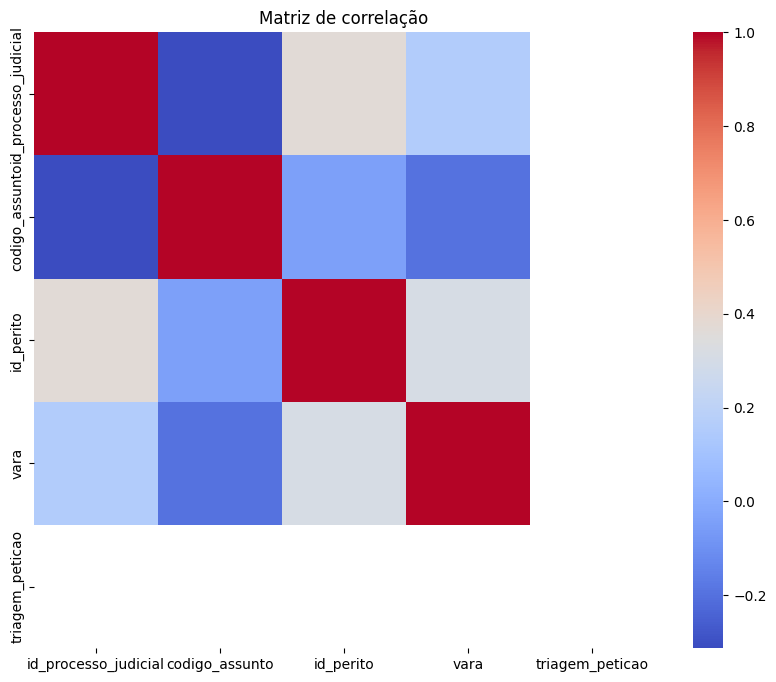

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = df_metadadosPericias.select_dtypes(include=['number']).columns
print('Variáveis numéricas disponíveis:', list(numeric_cols))

if len(numeric_cols) > 1:
    corr = df_metadadosPericias[numeric_cols].corr()
    print('Matriz de correlação:')
    display(corr)

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=False, cmap='coolwarm')
    plt.title('Matriz de correlação')
    plt.show()
else:
    print('Não há variáveis numéricas suficientes para calcular correlação.')

## Outliers em variáveis numéricas

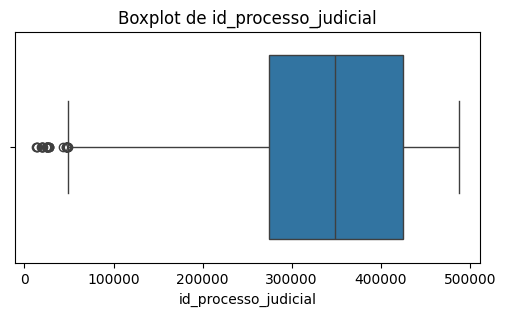

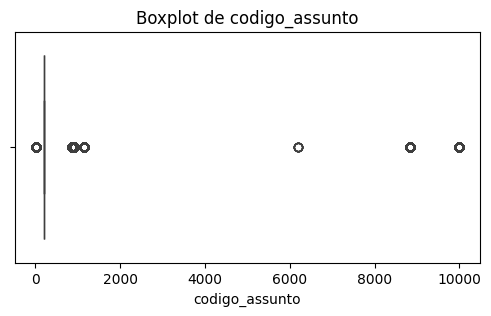

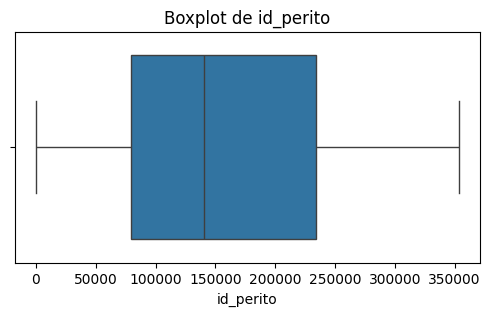

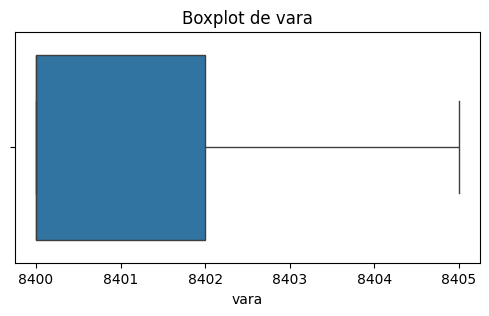

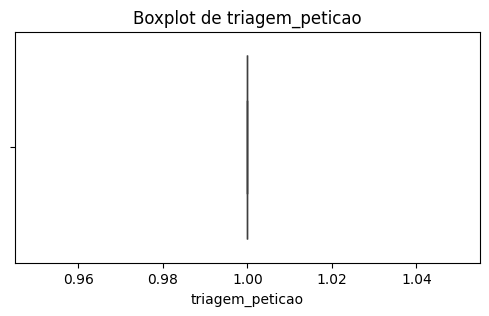

In [24]:
if len(numeric_cols) > 0:
    for col in numeric_cols:
        plt.figure(figsize=(6, 3))
        sns.boxplot(data=df_metadadosPericias, x=col)
        plt.title(f'Boxplot de {col}')
        plt.show()
else:
    print('Não há variáveis numéricas para gerar boxplots.')

## Distribuições

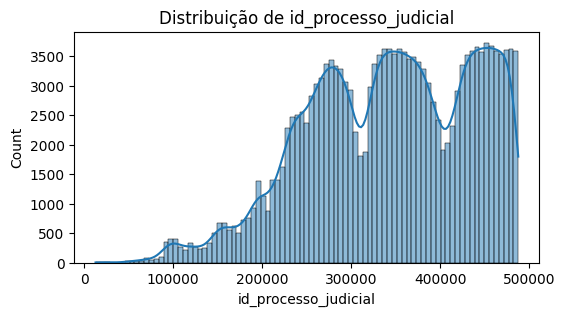

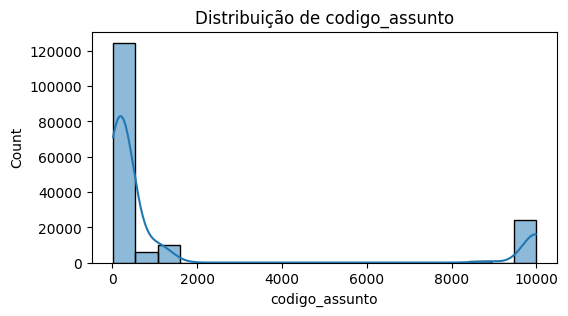

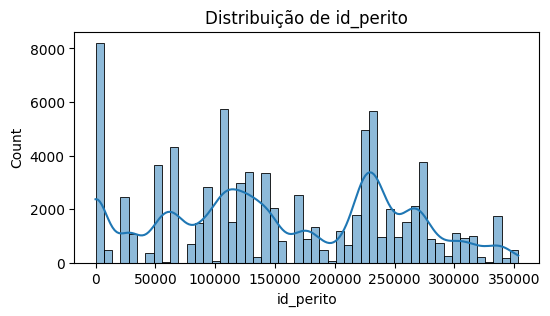

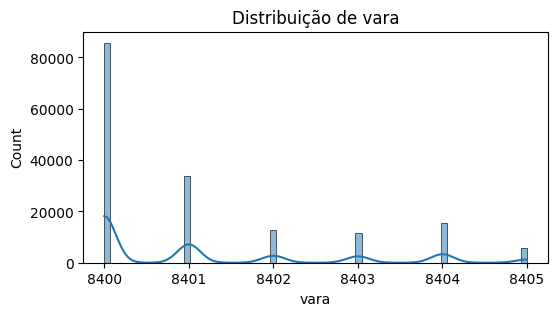

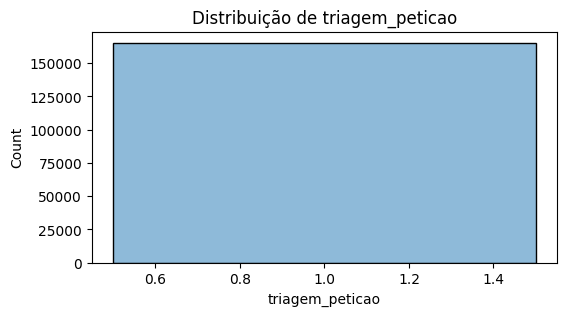

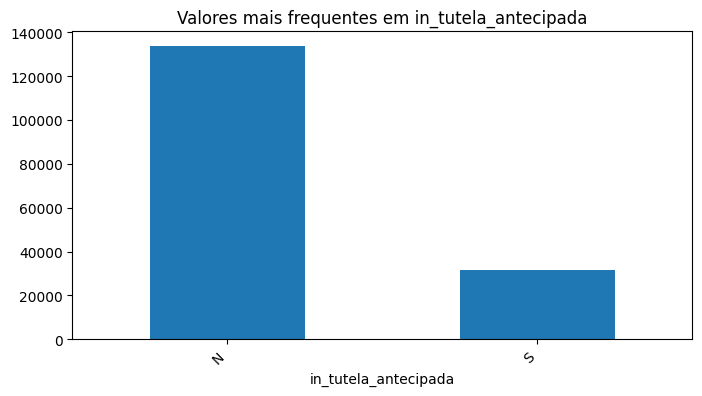

KeyError: 'nm_juizado'

<Figure size 800x400 with 0 Axes>

In [25]:
for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(df_metadadosPericias[col].dropna(), kde=True)
    plt.title(f'Distribuição de {col}')
    plt.show()

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    df_metadadosPericias[col].value_counts().head(10).plot(kind='bar')
    plt.title(f'Valores mais frequentes em {col}')
    plt.xticks(rotation=45, ha='right')
    plt.show()

## Tratamento de dados

In [26]:
# Preenchimento de valores faltantes
df_tratado = df_metadadosPericias.copy()

for col in df_tratado.select_dtypes(include=['number']).columns:
    df_tratado[col] = df_tratado[col].fillna(0)

for col in df_tratado.select_dtypes(include=['object', 'category']).columns:
    df_tratado[col] = df_tratado[col].fillna('não se aplica')

# Remoção de linhas duplicadas
before = len(df_tratado)
df_tratado = df_tratado.drop_duplicates()
after = len(df_tratado)
print(f'Linhas duplicadas removidas: {before - after}')

# Encoding de variáveis categóricas
for col in df_tratado.select_dtypes(include=['object', 'category']).columns:
    df_tratado[col] = df_tratado[col].astype('category').cat.codes

# Normalização das colunas numéricas
from sklearn.preprocessing import StandardScaler

numeric_features = df_tratado.select_dtypes(include=['number']).columns
scaler = StandardScaler()
df_tratado[numeric_features] = scaler.fit_transform(df_tratado[numeric_features])

print('Dataset tratado com sucesso.')
display(df_tratado.head())

df_tratado.to_csv('norm_df_metadadosPericias.csv', index=False)
print('Checkpoint salvo em norm_df_metadadosPericias.csv')

Linhas duplicadas removidas: 0
Dataset tratado com sucesso.


,id_processo_judicial,in_tutela_antecipada,ds_cidade,codigo_assunto,ds_complemento_assunto_judicial,detalhe_assunto_1,detalhe_assunto_2,id_perito,ds_especialidade,ds_complemento_especialidade,ds_status_pericia,vara,triagem_peticao,label_especialidade,requer_pericia
0,1.433433,-0.487774,1.271249,-0.446623,-0.620929,-0.670407,0.498676,1.890280,-0.785344,-0.458374,-1.355085,1.904991,0.0,-0.195148,0.985721
1,-0.944329,-0.487774,-1.699017,-0.446623,-0.620929,-0.810021,0.498676,0.915010,-0.785344,-2.098243,-0.604509,0.579547,0.0,-1.518984,0.985721
2,-2.664994,-0.487774,-0.213884,2.376748,1.877515,1.842645,-1.645071,-0.760445,0.954355,0.771528,0.896643,-0.083176,0.0,0.797729,-1.014486
3,-0.614218,-0.487774,-0.213884,-0.446623,-0.620929,-0.670407,0.498676,0.147044,-0.785344,-0.458374,-2.105661,-0.083176,0.0,-0.195148,0.985721
4,0.006593,-0.487774,-2.441584,-0.446623,-0.620929,-0.670407,0.498676,1.612466,-0.785344,-2.098243,-0.604509,1.242269,0.0,-2.180902,0.985721


Checkpoint salvo em norm_df_metadadosPericias.csv
